[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zaskyaaaaa/TUGAS-UAS-STATISTIKA/blob/main/Zaskya_Putri_Safandra_F5212510009.ipynb)

# Prediksi Jumlah Pernikahan Kabupaten/Kota di Provinsi Sulawesi Tengah Berdasarkan Tingkat Pengangguran dan Jumlah Penduduk Tahun 2018–2025 Menggunakan Regresi Linear Berganda




#  Data Collecting

Dataset yang digunakan merupakan data jumlah pernikahan, jumlah penduduk, dan tingkat pengangguran terbuka menurut kabupaten/kota di Provinsi Sulawesi Tengah dari tahun 2018 hingga 2025 berdasarkan data dari BPS (Badan Pusat Statistik). Dataset ini memuat informasi mengenai jumlah penduduk, tingkat pengangguran terbuka, dan jumlah peristiwa pernikahan di setiap kabupaten/kota.

**Variabel yang digunakan:**
- **Variabel Target (Y):** `Jumlah_Pernikahan_Y` — Jumlah peristiwa pernikahan
- **Variabel Prediktor (X):**
  - `Jumlah_Penduduk_X1` — Jumlah penduduk (dalam ribuan jiwa)
  - `Tingkat_Pengangguran_X2` — Tingkat pengangguran terbuka (%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')


In [2]:
file_path = "dataset.csv"
df = pd.read_csv(file_path)

print("Dataset berhasil dimuat!")

Dataset berhasil dimuat!


#  Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan mengeksplorasi dataset untuk memahami struktur data, distribusi variabel, dan hubungan antar variabel sebelum membangun model prediksi.

In [3]:
print("=== 5 Data Pertama ===")
df.head()

=== 5 Data Pertama ===


,Kabupaten_Kota,Tahun,Jumlah_Penduduk_X1,Tingkat_Pengangguran_X2,Jumlah_Pernikahan_Y
0,Banggai,2018,371.30,3.00,2320
1,Banggai,2019,376.80,2.18,2182
2,Banggai,2020,362.30,2.42,2172
3,Banggai,2021,366.22,3.57,2112
4,Banggai,2022,370.97,3.09,1926


In [4]:
print("=== Statistik Deskriptif ===")
df.describe()

=== Statistik Deskriptif ===


,Tahun,Jumlah_Penduduk_X1,Tingkat_Pengangguran_X2,Jumlah_Pernikahan_Y
count,104.000000,104.000000,104.000000,104.000000
mean,2021.500000,235.603462,3.155000,1332.144231
std,2.302384,114.315513,1.204364,780.226149
min,2018.000000,70.400000,1.480000,166.000000
25%,2019.750000,141.375000,2.470000,620.500000
50%,2021.500000,232.555000,2.975000,1156.500000
75%,2023.250000,308.975000,3.352500,1843.500000
max,2025.000000,490.900000,8.380000,3155.000000


In [5]:
print("=== Informasi Dataset ===")
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Kabupaten_Kota           104 non-null    object 
 1   Tahun                    104 non-null    int64  
 2   Jumlah_Penduduk_X1       104 non-null    float64
 3   Tingkat_Pengangguran_X2  104 non-null    float64
 4   Jumlah_Pernikahan_Y      104 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 4.2+ KB


In [6]:
print(f"Jumlah baris (observasi) : {df.shape[0]}")
print(f"Jumlah kolom (variabel)  : {df.shape[1]}")
print(f"Jumlah kabupaten/kota    : {df['Kabupaten_Kota'].nunique()}")
print(f"Rentang tahun            : {df['Tahun'].min()} - {df['Tahun'].max()}")

Jumlah baris (observasi) : 104
Jumlah kolom (variabel)  : 5
Jumlah kabupaten/kota    : 13
Rentang tahun            : 2018 - 2025


In [7]:
print("=== Jumlah Nilai Kosong per Kolom ===")
print(df.isnull().sum())

=== Jumlah Nilai Kosong per Kolom ===
Kabupaten_Kota             0
Tahun                      0
Jumlah_Penduduk_X1         0
Tingkat_Pengangguran_X2    0
Jumlah_Pernikahan_Y        0
dtype: int64


In [8]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


==== Deteksi Outlier dengan IQR pada kolom Jumlah_Pernikahan_Y ====
Batas Bawah : -1214.0
Batas Atas  : 3678.0
Jumlah Jumlah_Pernikahan_Y Outlier : 0 baris dari total 104 baris data


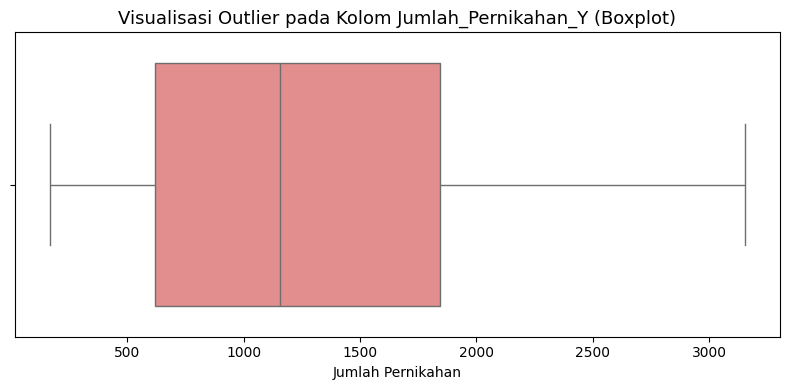

In [9]:
kolom_target = 'Jumlah_Pernikahan_Y'

print(f"==== Deteksi Outlier dengan IQR pada kolom {kolom_target} ====")

Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[kolom_target] < lower_bound) | (df[kolom_target] > upper_bound)]
print(f"Batas Bawah : {lower_bound}")
print(f"Batas Atas  : {upper_bound}")
print(f"Jumlah {kolom_target} Outlier : {len(outliers)} baris dari total {len(df)} baris data")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[kolom_target], color='lightcoral')
plt.title(f'Visualisasi Outlier pada Kolom {kolom_target} (Boxplot)', fontsize=13)
plt.xlabel('Jumlah Pernikahan')
plt.tight_layout()
plt.show()

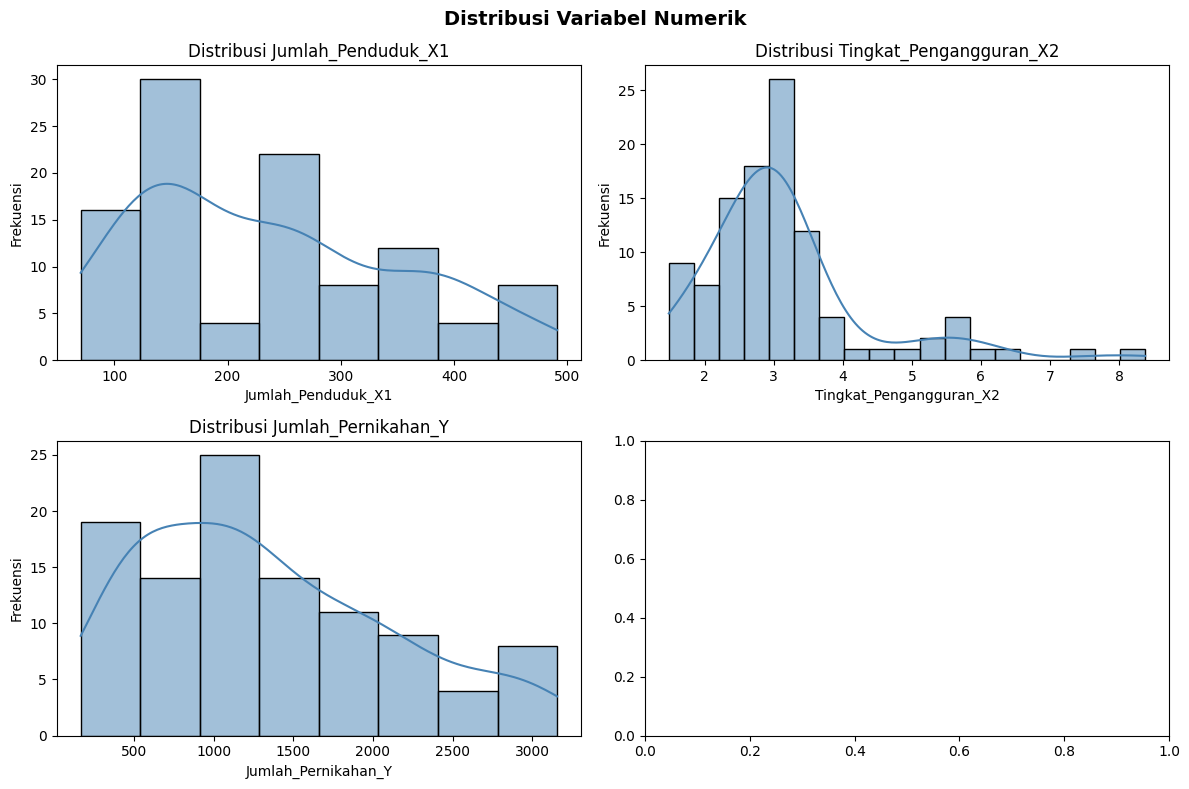

In [10]:
numerik_cols = ['Jumlah_Penduduk_X1', 'Tingkat_Pengangguran_X2', 'Jumlah_Pernikahan_Y']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), numerik_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

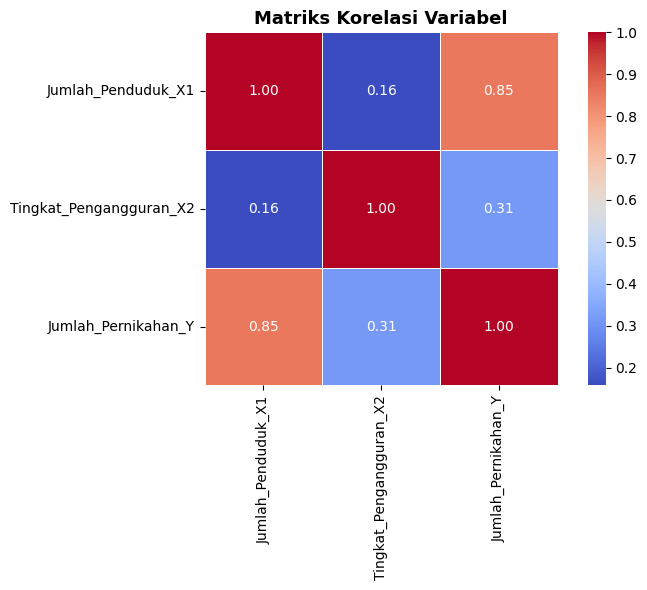


=== Nilai Korelasi terhadap Jumlah_Pernikahan_Y ===
Jumlah_Pernikahan_Y        1.000000
Jumlah_Penduduk_X1         0.852064
Tingkat_Pengangguran_X2    0.313510
Name: Jumlah_Pernikahan_Y, dtype: float64


In [11]:
plt.figure(figsize=(8, 6))
corr_matrix = df[numerik_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Matriks Korelasi Variabel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Nilai Korelasi terhadap Jumlah_Pernikahan_Y ===")
print(corr_matrix['Jumlah_Pernikahan_Y'].sort_values(ascending=False))

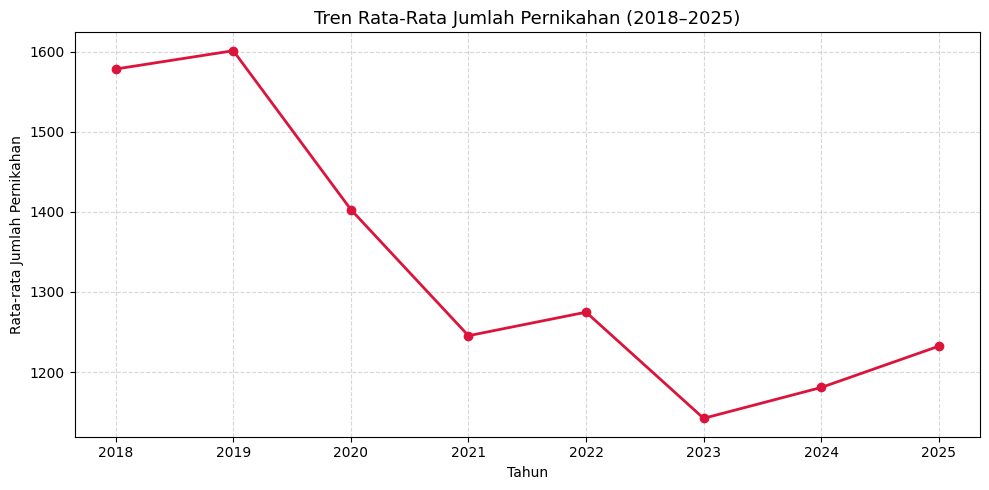

In [12]:
plt.figure(figsize=(10, 5))
trend = df.groupby('Tahun')['Jumlah_Pernikahan_Y'].mean().reset_index()
plt.plot(trend['Tahun'], trend['Jumlah_Pernikahan_Y'], marker='o', color='crimson', linewidth=2)
plt.title('Tren Rata-Rata Jumlah Pernikahan (2018–2025)', fontsize=13)
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Jumlah Pernikahan')
plt.xticks(trend['Tahun'].astype(int))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

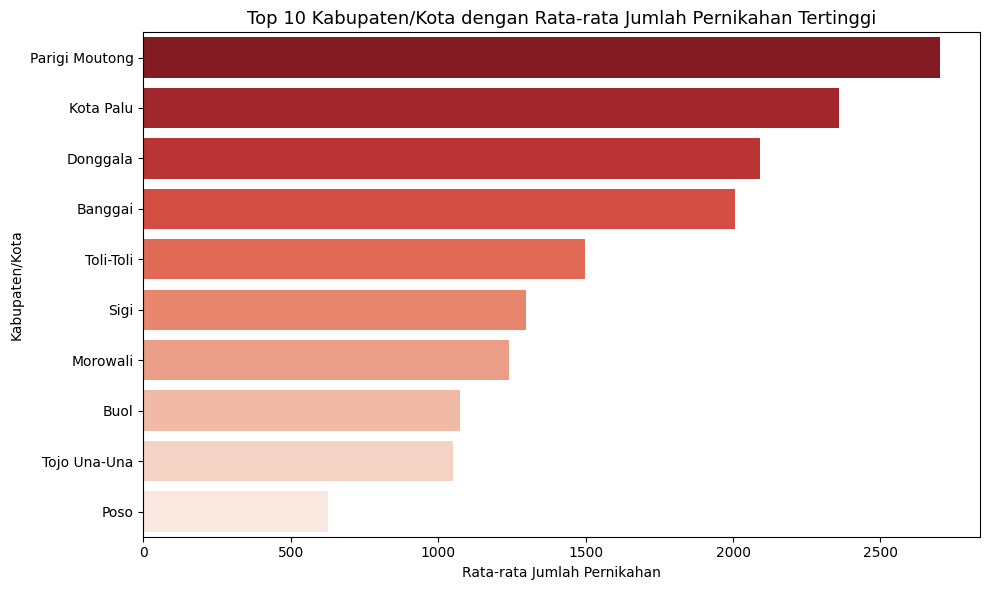

In [13]:
plt.figure(figsize=(10, 6))
top10 = df.groupby('Kabupaten_Kota')['Jumlah_Pernikahan_Y'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top10.values, y=top10.index, palette='Reds_r')
plt.title('Top 10 Kabupaten/Kota dengan Rata-rata Jumlah Pernikahan Tertinggi', fontsize=13)
plt.xlabel('Rata-rata Jumlah Pernikahan')
plt.ylabel('Kabupaten/Kota')
plt.tight_layout()
plt.show()

#  Data Preprocessing

Pada tahap ini dilakukan persiapan data sebelum dimasukkan ke dalam model, meliputi penanganan outlier, pemilihan fitur, dan pembagian data menjadi data latih dan data uji.

In [14]:
print(f"Jumlah data sebelum pembersihan outlier: {len(df)}")

df_clean = df[(df['Jumlah_Pernikahan_Y'] >= lower_bound) & (df['Jumlah_Pernikahan_Y'] <= upper_bound)].copy()

print(f"Jumlah data setelah pembersihan outlier: {len(df_clean)}")
print(f"Data yang dihapus: {len(df) - len(df_clean)} baris")

Jumlah data sebelum pembersihan outlier: 104
Jumlah data setelah pembersihan outlier: 104
Data yang dihapus: 0 baris


In [15]:
X = df_clean[['Jumlah_Penduduk_X1', 'Tingkat_Pengangguran_X2']]
y = df_clean['Jumlah_Pernikahan_Y']

print("=== Variabel Prediktor (X) ===")
print(X.head())
print(f"\nShape X: {X.shape}")
print(f"\n=== Variabel Target (y) ===")
print(y.head())

=== Variabel Prediktor (X) ===
   Jumlah_Penduduk_X1  Tingkat_Pengangguran_X2
0              371.30                     3.00
1              376.80                     2.18
2              362.30                     2.42
3              366.22                     3.57
4              370.97                     3.09

Shape X: (104, 2)

=== Variabel Target (y) ===
0    2320
1    2182
2    2172
3    2112
4    1926
Name: Jumlah_Pernikahan_Y, dtype: int64


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("=== Data Setelah Standardisasi ===")
print(X_scaled.describe().round(2))

=== Data Setelah Standardisasi ===
       Jumlah_Penduduk_X1  Tingkat_Pengangguran_X2
count              104.00                   104.00
mean                -0.00                    -0.00
std                  1.00                     1.00
min                 -1.45                    -1.40
25%                 -0.83                    -0.57
50%                 -0.03                    -0.15
75%                  0.64                     0.16
max                  2.24                     4.36


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Jumlah data latih (train) : {X_train.shape[0]} baris")
print(f"Jumlah data uji  (test)   : {X_test.shape[0]} baris")

Jumlah data latih (train) : 83 baris
Jumlah data uji  (test)   : 21 baris


#  Model Training

Pada tahap ini, model **Regresi Linear Berganda** dilatih menggunakan data latih. Regresi linear berganda digunakan untuk memodelkan hubungan antara satu variabel dependen (jumlah pernikahan) dengan dua atau lebih variabel independen (jumlah penduduk dan tingkat pengangguran).

Persamaan umum regresi linear berganda:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \varepsilon$$

Di mana:
- $Y$ = Jumlah Pernikahan
- $X_1$ = Jumlah Penduduk
- $X_2$ = Tingkat Pengangguran
- $\beta_0$ = Intercept (konstanta)
- $\beta_1, \beta_2$ = Koefisien regresi

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

print("=== PERSAMAAN REGRESI LINEAR BERGANDA ===")
print(f"Intercept (β₀) : {model.intercept_:.4f}")
print()
for nama, koef in zip(X.columns, model.coef_):
    print(f"Koefisien {nama} : {koef:.4f}")

y_pred = model.predict(X_test)

=== PERSAMAAN REGRESI LINEAR BERGANDA ===
Intercept (β₀) : 1312.7112

Koefisien Jumlah_Penduduk_X1 : 634.2247
Koefisien Tingkat_Pengangguran_X2 : 155.9481


In [19]:
b0 = model.intercept_
b1, b2 = model.coef_

print("=== PERSAMAAN MODEL ===")
print(f"Jumlah_Pernikahan_Y = {b0:.4f}")
print(f"                    + ({b1:.4f}) × Jumlah_Penduduk_X1")
print(f"                    + ({b2:.4f}) × Tingkat_Pengangguran_X2")

=== PERSAMAAN MODEL ===
Jumlah_Pernikahan_Y = 1312.7112
                    + (634.2247) × Jumlah_Penduduk_X1
                    + (155.9481) × Tingkat_Pengangguran_X2


#  Visualisasi Hasil Prediksi

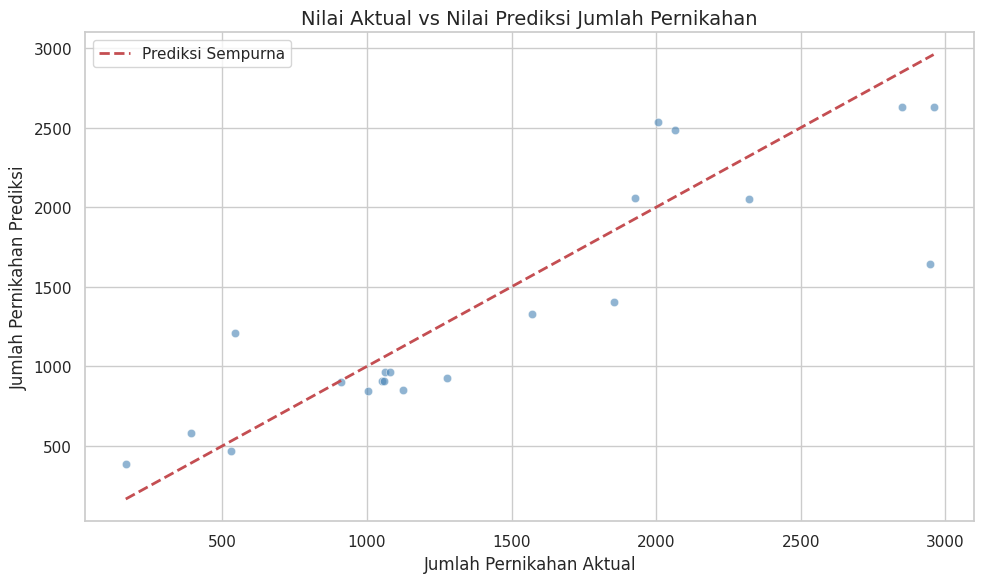

In [20]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Nilai Aktual vs Nilai Prediksi Jumlah Pernikahan', fontsize=14)
plt.xlabel('Jumlah Pernikahan Aktual', fontsize=12)
plt.ylabel('Jumlah Pernikahan Prediksi', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

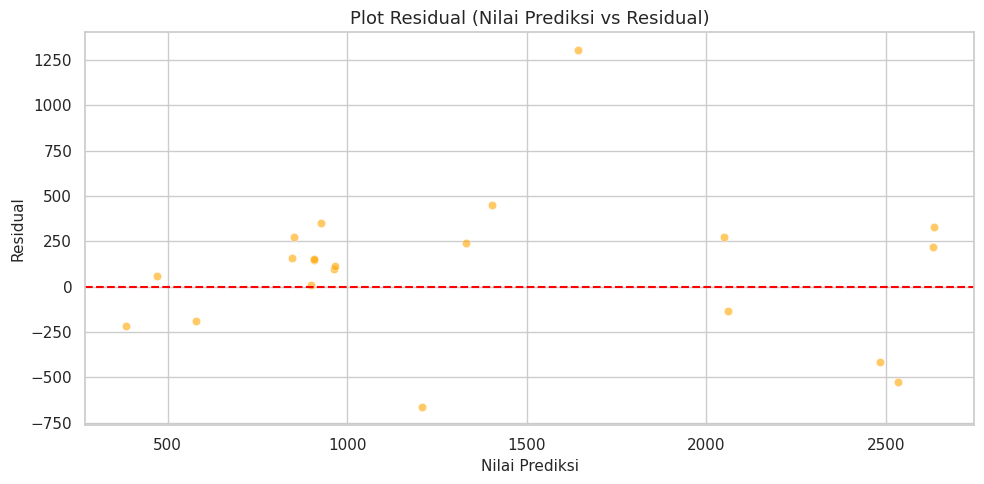

In [21]:
residual = y_test.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residual, alpha=0.6, color='orange', edgecolors='white', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Plot Residual (Nilai Prediksi vs Residual)', fontsize=13)
plt.xlabel('Nilai Prediksi', fontsize=11)
plt.ylabel('Residual', fontsize=11)
plt.tight_layout()
plt.show()

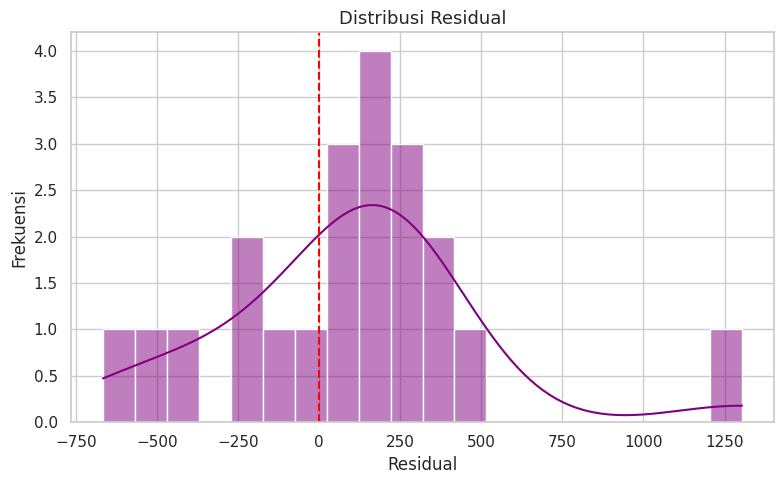

In [22]:
plt.figure(figsize=(8, 5))
sns.histplot(residual, kde=True, color='purple', bins=20)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Distribusi Residual', fontsize=13)
plt.xlabel('Residual')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

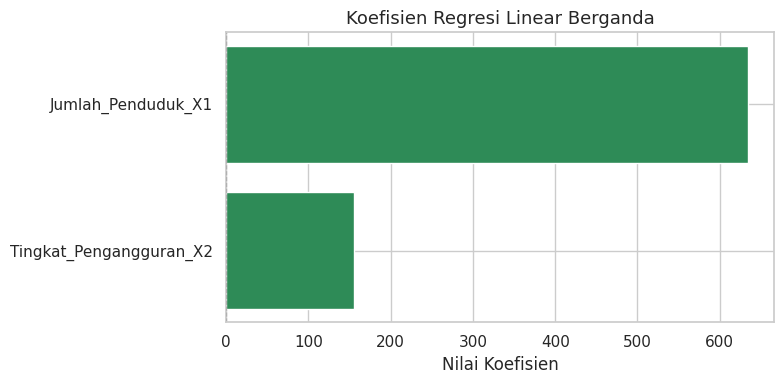

Interpretasi:
- Koefisien positif (hijau) → variabel meningkatkan jumlah pernikahan
- Koefisien negatif (merah) → variabel menurunkan jumlah pernikahan


In [23]:
koef_df = pd.DataFrame({
    'Variabel': X.columns,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['crimson' if k < 0 else 'seagreen' for k in koef_df['Koefisien']]
plt.barh(koef_df['Variabel'], koef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Koefisien Regresi Linear Berganda', fontsize=13)
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

print("Interpretasi:")
print("- Koefisien positif (hijau) → variabel meningkatkan jumlah pernikahan")
print("- Koefisien negatif (merah) → variabel menurunkan jumlah pernikahan")

#  Evaluasi Model

Evaluasi model dilakukan untuk mengukur seberapa baik model dalam memprediksi jumlah pernikahan. Metrik yang digunakan:

| Metrik | Keterangan |
| ------ | ----------- |
| MAE    | Mean Absolute Error — rata-rata kesalahan absolut antara nilai aktual dan prediksi |
| MSE    | Mean Squared Error — rata-rata kuadrat kesalahan; memberi hukuman lebih pada error besar |
| RMSE   | Root Mean Squared Error — akar dari MSE; mudah diinterpretasikan karena satuannya sama dengan target |
| R²     | Koefisien determinasi — proporsi variansi target yang dapat dijelaskan oleh model (0–1, semakin mendekati 1 semakin baik) |

In [24]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===")
print(f"R²   (Koefisien Determinasi) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE  (Mean Absolute Error)   : {mae:.4f}")
print(f"MSE  (Mean Squared Error)    : {mse:.4f}")
print(f"RMSE (Root MSE)              : {rmse:.4f}")

print("\n=== INTERPRETASI ===")
if r2 >= 0.7:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi jumlah pernikahan")
    print("dapat dijelaskan oleh variabel prediktor yang digunakan. Model CUKUP BAIK.")
elif r2 >= 0.5:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi jumlah pernikahan")
    print("dapat dijelaskan oleh variabel prediktor. Model CUKUP MODERAT.")
else:
    print(f"Model memiliki R² = {r2:.2f}, artinya {r2*100:.1f}% variasi jumlah pernikahan")
    print("dapat dijelaskan oleh variabel prediktor. Perlu penambahan fitur atau transformasi data.")


=== EVALUASI MODEL REGRESI LINEAR BERGANDA ===
R²   (Koefisien Determinasi) : 0.7513  (75.13%)
MAE  (Mean Absolute Error)   : 300.9088
MSE  (Mean Squared Error)    : 165630.2780
RMSE (Root MSE)              : 406.9770

=== INTERPRETASI ===
Model memiliki R² = 0.75, artinya 75.1% variasi jumlah pernikahan
dapat dijelaskan oleh variabel prediktor yang digunakan. Model CUKUP BAIK.


In [25]:
hasil_uji = pd.DataFrame({
    'Jumlah Pernikahan Aktual': y_test.values[:10],
    'Jumlah Pernikahan Prediksi': np.round(y_pred[:10], 2),
    'Selisih (Error)': np.abs(y_test.values[:10] - y_pred[:10]).round(2)
})

print("=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===")
print(hasil_uji.to_string(index=False))

=== CONTOH HASIL PREDIKSI (10 Data Pertama) ===
 Jumlah Pernikahan Aktual  Jumlah Pernikahan Prediksi  Selisih (Error)
                     1002                      845.61           156.39
                     2959                     2632.52           326.48
                     2849                     2631.60           217.40
                     1053                      908.50           144.50
                     2066                     2484.09           418.09
                      909                      899.12             9.88
                     1063                      963.66            99.34
                     2005                     2532.09           527.09
                      392                      579.67           187.67
                     2320                     2049.04           270.96


#  Deployment / Prediksi Data Baru

Pada tahap ini, model yang telah dilatih digunakan untuk memprediksi jumlah pernikahan berdasarkan input data baru dari pengguna.

In [26]:
print("=== SISTEM PREDIKSI JUMLAH PERNIKAHAN ===")
print("Masukkan data berikut untuk memprediksi jumlah pernikahan:")
print()

jumlah_penduduk      = 400.0
tingkat_pengangguran = 5.5

print(f"Input Data Baru:")
print(f"  Jumlah Penduduk         : {jumlah_penduduk} ribu jiwa")
print(f"  Tingkat Pengangguran    : {tingkat_pengangguran}%")

data_baru = pd.DataFrame([{
    'Jumlah_Penduduk_X1': jumlah_penduduk,
    'Tingkat_Pengangguran_X2': tingkat_pengangguran
}])

data_baru_scaled = scaler.transform(data_baru)

prediksi = model.predict(data_baru_scaled)[0]

print()
print("=" * 45)
print(f"HASIL PREDIKSI:")
print(f"  Jumlah Pernikahan : {prediksi:.2f} peristiwa")
print("=" * 45)

rata_seluruh = df['Jumlah_Pernikahan_Y'].mean()
print(f"\nRata-rata seluruh kabupaten/kota (2018-2025) : {rata_seluruh:.2f} peristiwa")

if prediksi > rata_seluruh:
    print(f"Prediksi MELEBIHI rata-rata → Jumlah Pernikahan TINGGI")
else:
    print(f"Prediksi DI BAWAH rata-rata → Jumlah Pernikahan RENDAH")

=== SISTEM PREDIKSI JUMLAH PERNIKAHAN ===
Masukkan data berikut untuk memprediksi jumlah pernikahan:

Input Data Baru:
  Jumlah Penduduk         : 400.0 ribu jiwa
  Tingkat Pengangguran    : 5.5%

HASIL PREDIKSI:
  Jumlah Pernikahan : 2534.32 peristiwa

Rata-rata seluruh kabupaten/kota (2018-2025) : 1332.14 peristiwa
Prediksi MELEBIHI rata-rata → Jumlah Pernikahan TINGGI


In [27]:
# KESIMPULAN

print("=" * 55)
print("KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA")
print("=" * 55)
print()
print("Judul:")
print("  Prediksi Jumlah Pernikahan Kabupaten/Kota di")
print("  Provinsi Sulawesi Tengah Tahun 2018-2025")
print()
print("Variabel Prediktor (X):")
print("  1. Jumlah Penduduk (Jumlah_Penduduk_X1)")
print("  2. Tingkat Pengangguran Terbuka (Tingkat_Pengangguran_X2)")
print()
print("Variabel Target (Y):")
print("  Jumlah Pernikahan (Jumlah_Pernikahan_Y)")
print()
print("Persamaan Model:")
print(f"  Y = {b0:.4f} + ({b1:.4f})×X₁ + ({b2:.4f})×X₂")
print()
print("Hasil Evaluasi:")
print(f"  R²   = {r2:.4f}  → Model menjelaskan {r2*100:.2f}% variansi data")
print(f"  MAE  = {mae:.4f}  → Rata-rata kesalahan absolut")
print(f"  RMSE = {rmse:.4f}  → Ukuran error yang mudah diinterpretasikan")
print()
print("=" * 55)

KESIMPULAN ANALISIS REGRESI LINEAR BERGANDA

Judul:
  Prediksi Jumlah Pernikahan Kabupaten/Kota di
  Provinsi Sulawesi Tengah Tahun 2018-2025

Variabel Prediktor (X):
  1. Jumlah Penduduk (Jumlah_Penduduk_X1)
  2. Tingkat Pengangguran Terbuka (Tingkat_Pengangguran_X2)

Variabel Target (Y):
  Jumlah Pernikahan (Jumlah_Pernikahan_Y)

Persamaan Model:
  Y = 1312.7112 + (634.2247)×X₁ + (155.9481)×X₂

Hasil Evaluasi:
  R²   = 0.7513  → Model menjelaskan 75.13% variansi data
  MAE  = 300.9088  → Rata-rata kesalahan absolut
  RMSE = 406.9770  → Ukuran error yang mudah diinterpretasikan

